# Computing P-values and Confidence Intervals

## 📚 Learning Objectives

By completing this notebook, you will:
- Compute p-values for hypothesis tests
- Calculate confidence intervals for population parameters
- Interpret p-values and confidence intervals
- Understand the relationship between p-values and confidence intervals

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 3, lesson 01 "Regression vs Classification" — a single accuracy number with nothing around it; here you learn to attach an interval.

**Used later in:** Course 04 (AIAT 114) — Unit 2 — reporting cross-validation scores with their spread instead of one figure.

---

This notebook covers practical activities from **Course 03, Unit 5**:
- Computing p-values and confidence intervals

---

## Introduction

**P-values** measure evidence against the null hypothesis, and **confidence intervals** provide a range of plausible values for population parameters.


---

## 📌 Real case: 120 researchers, six false statements, and more than three endorsed

Rink Hoekstra, Richard Morey, Jeffrey Rouder and Eric-Jan Wagenmakers published
**"Robust misinterpretation of confidence intervals"** in *Psychonomic Bulletin & Review* (2014). They gave
**120 researchers and 442 students** — all in psychology — a fictitious result reported as a 95% confidence
interval, together with **six** statements about what it meant. **All six statements were false.** Both
groups endorsed, on average, **more than three of them**. Self-declared statistical experience made no
difference, and, in the authors' words, "researchers hardly outperformed the students, even though the
students had not received any education on statistical inference whatsoever."

The statements that catch people are the natural-sounding ones: "there is a 95% probability the true mean
lies between these numbers", "we can be 95% confident the true mean is in this interval". Both are wrong.
The true mean is a fixed number; it is either in your interval or it is not. The 95% is a property of the
**procedure** — of the intervals you *would* build over many repetitions — not of the one interval on your
screen. The notebook says this correctly: "if we repeated this experiment many times, 95% of the intervals
built this way would contain the true mean."

**What goes wrong without this.** A confidence interval is the most common way uncertainty reaches a
decision-maker, and the most commonly mis-stated. Getting the sentence right is not pedantry; it is the
difference between "we are 95% sure" (a claim you cannot support) and "this method is right 19 times in
20" (a claim you can).


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: NumPy, Matplotlib, scipy.stats for the t-tests and interval formulas,
# and pandas to load the real Titanic records.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from pathlib import Path


def data_path(filename):
    """Locate a shared raw dataset by walking up from this notebook's folder.

    All courses share one datasets folder, so we search upward for it instead of
    hard-coding a fragile relative path.
    """
    for base in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        candidate = base / "Course 04" / "datasets" / "raw" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"{filename} not found under any Course 04/datasets/raw")


# Confirm the environment is ready before any math starts.
print("✅ Libraries imported!")
print("\nComputing P-values and Confidence Intervals")
print("=" * 60)


✅ Libraries imported!

Computing P-values and Confidence Intervals


## Part 1: Computing P-values


In [2]:
# Compute p-values for three hypothesized means against the same REAL sample.
# Watch the p-value collapse as H0 drifts from what the data says - that is evidence accumulating.

print("=" * 60)
print("Part 1: Computing P-values")
print("=" * 60)

# Real population: the 714 Titanic passengers whose age was recorded. We happen to hold
# ALL of them, so we know the population mean exactly - which lets us check later whether
# our interval actually caught it. Then we draw one random sample of 100, the way a real
# survey would, and do inference from that sample alone.
titanic = pd.read_csv(data_path("titanic.csv"))
population = titanic["Age"].dropna().to_numpy()
true_mean = population.mean()          # a genuine population parameter, not an invented one

rng = np.random.default_rng(42)        # sampling is simulated on purpose; the ages are real
sample = rng.choice(population, size=100, replace=False)
sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1)

print(f"\nPopulation: {len(population)} recorded Titanic passenger ages")
print(f"Population mean age: {true_mean:.4f} years")
print(f"\nSample drawn from it: n = {len(sample)}")
print(f"Sample mean: {sample_mean:.4f}")
print(f"Sample std:  {sample_std:.4f}")

# P-value: probability of observing data this extreme IF H0 is true
# One-sample t-test: H0: mu = hypothesized value
for h0 in [30, 33, 36]:
    t_stat, p_value = stats.ttest_1samp(sample, h0)
    decision = "Reject H0 (p < 0.05)" if p_value < 0.05 else "Fail to reject H0 (p >= 0.05)"
    print(f"\nTest - H0: mu = {h0}")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  p-value:     {p_value:.4f}")
    print(f"  Decision:    {decision}")

print("\nInterpretation: A small p-value means the observed sample would be")
print("very unlikely if H0 were true - evidence AGAINST H0.")

print("\n✅ P-values computed on a real sample!")


Part 1: Computing P-values

Population: 714 recorded Titanic passenger ages
Population mean age: 29.6991 years

Sample drawn from it: n = 100
Sample mean: 29.8025
Sample std:  14.7211

Test - H0: mu = 30
  t-statistic: -0.1342
  p-value:     0.8935
  Decision:    Fail to reject H0 (p >= 0.05)

Test - H0: mu = 33
  t-statistic: -2.1720
  p-value:     0.0322
  Decision:    Reject H0 (p < 0.05)

Test - H0: mu = 36
  t-statistic: -4.2099
  p-value:     0.0001
  Decision:    Reject H0 (p < 0.05)

Interpretation: A small p-value means the observed sample would be
very unlikely if H0 were true - evidence AGAINST H0.

✅ P-values computed on a real sample!


## Part 2: Computing Confidence Intervals


In [3]:
# Build confidence intervals for the mean and see how the confidence level sets the width.
# More confidence costs a wider interval — certainty is never free.

print("\n" + "=" * 60)
print("Part 2: Computing Confidence Intervals")
print("=" * 60)

# 95% confidence interval for the mean (t-distribution)
sem = stats.sem(sample)  # Standard error of the mean
ci_lower, ci_upper = stats.t.interval(0.95, df=len(sample) - 1,
                                      loc=sample_mean, scale=sem)

print(f"\nSample mean:     {sample_mean:.4f}")
print(f"Standard error:  {sem:.4f}")
print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
in_ci = ci_lower <= true_mean <= ci_upper
print(f"Contains the true population mean ({true_mean:.2f})? {'Yes' if in_ci else 'No'}")
print("We can check this only because we happen to hold the whole population. In a real")
print("study you never can - which is exactly why the interval is stated with a confidence level.")

# Effect of confidence level: higher confidence -> wider interval
print("\nEffect of confidence level:")
for conf in [0.90, 0.95, 0.99]:
    lo, hi = stats.t.interval(conf, df=len(sample) - 1, loc=sample_mean, scale=sem)
    print(f"  {conf:.0%} CI: [{lo:.4f}, {hi:.4f}]  (width: {hi - lo:.4f})")

print("\nInterpretation: If we repeated this experiment many times,")
print("95% of the intervals built this way would contain the true mean.")

print("\n\u2705 Confidence intervals computed!")



Part 2: Computing Confidence Intervals

Sample mean:     29.8025
Standard error:  1.4721
95% CI: [26.8815, 32.7235]
Contains the true population mean (29.70)? Yes
We can check this only because we happen to hold the whole population. In a real
study you never can - which is exactly why the interval is stated with a confidence level.

Effect of confidence level:
  90% CI: [27.3582, 32.2468]  (width: 4.8886)
  95% CI: [26.8815, 32.7235]  (width: 5.8420)
  99% CI: [25.9361, 33.6689]  (width: 7.7327)

Interpretation: If we repeated this experiment many times,
95% of the intervals built this way would contain the true mean.

✅ Confidence intervals computed!


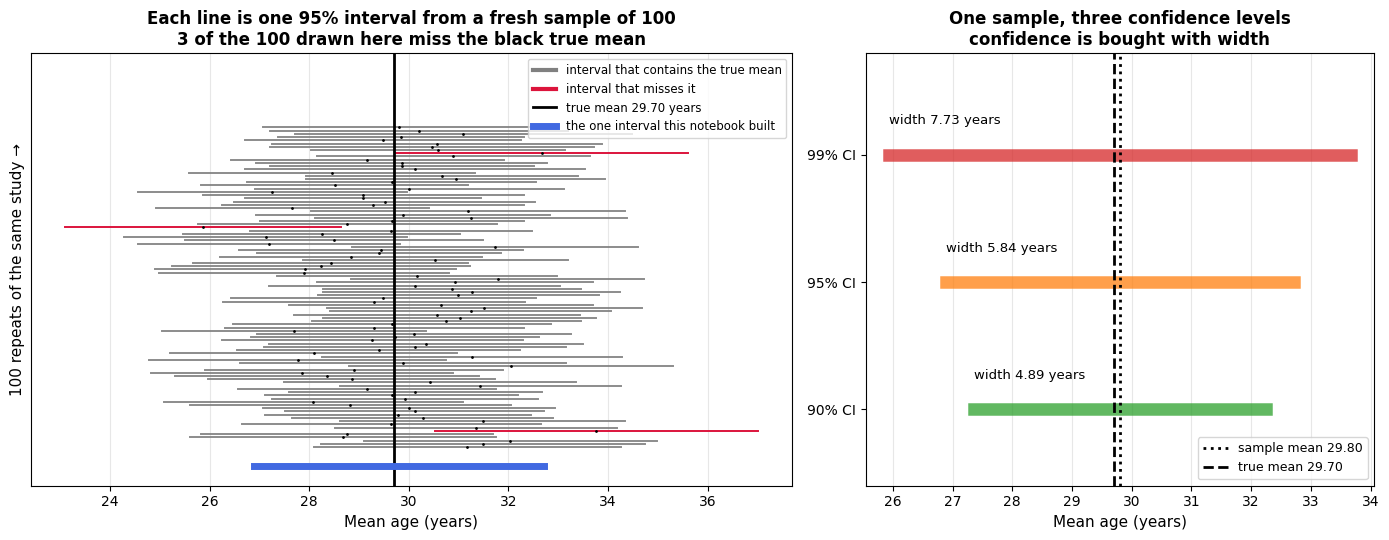


Coverage measured over 2000 repeats of the study (n = 100 each):
  nominal level    intervals that caught the true mean
           90%                                 92.5%
           95%                                 96.4%
           99%                                 99.6%

📊 Read the figure:
  - Left: 100 repeats of this exact study. 3 intervals are crimson: they do not
    contain the black line, and nothing about them looks wrong from the inside.
    That is what '95% confidence' means - a hit rate of the METHOD across repeats,
    not a probability attached to the blue interval you happen to have.
  - The blue bar at the bottom is the single interval computed earlier in this
    notebook. In a real study it is the ONLY line you would ever see.
  - Right: the same 100 ages, three confidence levels. Going from 90% to 99% does not
    add knowledge; it adds width - the statement gets vaguer until it is safe.
  - Note in the table above that the measured coverage runs a little HI

In [4]:
# The sentence everyone gets wrong, drawn.
# "95% confidence" is not a property of the one interval you built - it is a property of the
# PROCEDURE that built it. The only way to see that is to run the procedure many times, so
# that is what this cell does: repeat the whole study, keep every interval, and count.
# (The 714 ages are real; only the act of drawing a fresh sample of 100 is simulated - and
#  repeated sampling IS the thing being taught here.)

rng_repeat = np.random.default_rng(7)
n_draw = len(sample)          # same sample size as the study above: 100
n_repeats = 2000              # how many times we pretend to redo the whole study
n_shown = 100                 # how many of those repeats the left panel can legibly draw

# Draw n_repeats independent samples of 100 ages, without replacement, all at once.
order = np.argsort(rng_repeat.random((n_repeats, len(population))), axis=1)[:, :n_draw]
repeat_samples = population[order]
means = repeat_samples.mean(axis=1)
sems = repeat_samples.std(axis=1, ddof=1) / np.sqrt(n_draw)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={'width_ratios': [1.5, 1]})

# --- Left: 100 repeats of the same study, one interval each --------------------------------
t_crit = stats.t.ppf(0.975, df=n_draw - 1)
los, his = means - t_crit * sems, means + t_crit * sems
covers = (los <= true_mean) & (true_mean <= his)

for i in range(n_shown):
    axes[0].plot([los[i], his[i]], [i, i],
                 color='grey' if covers[i] else 'crimson',
                 linewidth=1.4, alpha=0.9 if covers[i] else 1.0)
    axes[0].plot(means[i], i, '.', color='black', markersize=2)

axes[0].axvline(true_mean, color='black', linewidth=2)
axes[0].plot([ci_lower, ci_upper], [-6, -6], color='royalblue', linewidth=5)
# Headroom at the top so the legend never sits on top of an interval.
axes[0].set_ylim(-12, n_shown + 22)
axes[0].set_yticks([])
axes[0].set_xlabel('Mean age (years)', fontsize=11)
axes[0].set_ylabel(f'{n_shown} repeats of the same study →', fontsize=11)
missed_shown = int((~covers[:n_shown]).sum())
axes[0].set_title(f'Each line is one 95% interval from a fresh sample of {n_draw}\n'
                  f'{missed_shown} of the {n_shown} drawn here miss the black true mean',
                  fontsize=12, fontweight='bold')
axes[0].legend(handles=[
    plt.Line2D([], [], color='grey', linewidth=3, label='interval that contains the true mean'),
    plt.Line2D([], [], color='crimson', linewidth=3, label='interval that misses it'),
    plt.Line2D([], [], color='black', linewidth=2, label=f'true mean {true_mean:.2f} years'),
    plt.Line2D([], [], color='royalblue', linewidth=5,
               label='the one interval this notebook built'),
], fontsize=8.5, loc='upper right')
axes[0].grid(True, alpha=0.3, axis='x')

# --- Right: what a higher confidence level actually buys, on the SAME sample ----------------
levels = [0.90, 0.95, 0.99]
for j, conf in enumerate(levels):
    lo, hi = stats.t.interval(conf, df=n_draw - 1, loc=sample_mean, scale=stats.sem(sample))
    axes[1].plot([lo, hi], [j, j], linewidth=9, alpha=0.75,
                 color=['tab:green', 'tab:orange', 'tab:red'][j])
    # Label at the left end: the mean lines sit in the middle of every bar.
    axes[1].text(lo, j + 0.24, f'width {hi - lo:.2f} years', ha='left', fontsize=9.5)
axes[1].axvline(sample_mean, color='black', linestyle=':', linewidth=2,
                label=f'sample mean {sample_mean:.2f}')
axes[1].axvline(true_mean, color='black', linestyle='--', linewidth=2,
                label=f'true mean {true_mean:.2f}')
axes[1].set_yticks(range(len(levels)))
axes[1].set_yticklabels([f'{int(c * 100)}% CI' for c in levels])
axes[1].set_ylim(-0.6, len(levels) - 0.2)
axes[1].set_xlabel('Mean age (years)', fontsize=11)
axes[1].set_title('One sample, three confidence levels\nconfidence is bought with width',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9, loc='lower right')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# The honest count, over many more repeats than the panel can draw.
print(f"\nCoverage measured over {n_repeats} repeats of the study (n = {n_draw} each):")
print(f"{'nominal level':>15} {'intervals that caught the true mean':>38}")
for conf in levels:
    tc = stats.t.ppf(0.5 + conf / 2, df=n_draw - 1)
    cov = np.mean(np.abs(means - true_mean) <= tc * sems)
    print(f"{conf:>14.0%} {cov:>37.1%}")

print("\n📊 Read the figure:")
print(f"  - Left: {n_shown} repeats of this exact study. {missed_shown} intervals are crimson: they do not")
print("    contain the black line, and nothing about them looks wrong from the inside.")
print("    That is what '95% confidence' means - a hit rate of the METHOD across repeats,")
print("    not a probability attached to the blue interval you happen to have.")
print("  - The blue bar at the bottom is the single interval computed earlier in this")
print("    notebook. In a real study it is the ONLY line you would ever see.")
print("  - Right: the same 100 ages, three confidence levels. Going from 90% to 99% does not")
print("    add knowledge; it adds width - the statement gets vaguer until it is safe.")
print("  - Note in the table above that the measured coverage runs a little HIGHER than the")
print("    nominal level. That is not luck: we sample 100 of only 714 passengers without")
print("    replacement, so the true standard error is smaller than the s/sqrt(n) the formula")
print("    assumes, and the intervals are slightly too wide. Real surveys correct for this")
print("    with a finite-population factor.")


**📖 What to see in the figure above.** The left panel is the answer to the question
Hoekstra's 120 researchers got wrong. Every horizontal line is a complete repeat of this study
— a fresh sample of 100 passengers, a fresh mean, a fresh 95% interval. Most lines cross the
black true mean; the crimson ones do not, and there is nothing visibly defective about them.
The 95% lives in the *proportion of lines*, not in any single line, which is why "there is a
95% probability the true mean is in my interval" is the wrong sentence. The blue bar is the one
interval this notebook actually computed: in real work it is the only line you ever get to see,
and you never learn which colour it was. The right panel prices the alternative of "just be
more confident": the same 100 observations, an interval that grows from about 4.9 to about 7.7
years wide as the level goes from 90% to 99%.

## Part 3: Relationship Between P-values and Confidence Intervals



Part 3: Relationship Between P-values and Confidence Intervals

Key Relationship:
  If 95% CI excludes the hypothesized value, then p < 0.05
  If 95% CI includes the hypothesized value, then p ≥ 0.05

Testing different hypothesized means:
  95% CI: [26.8815, 32.7235]

Hypothesized Value | In CI? | p-value | Reject H0?
    24.0         | No    | 0.0002 | Yes     
    27.0         | Yes   | 0.0599 | No      
    30.0         | Yes   | 0.8935 | No      
    33.0         | No    | 0.0322 | Yes     
    36.0         | No    | 0.0001 | Yes     


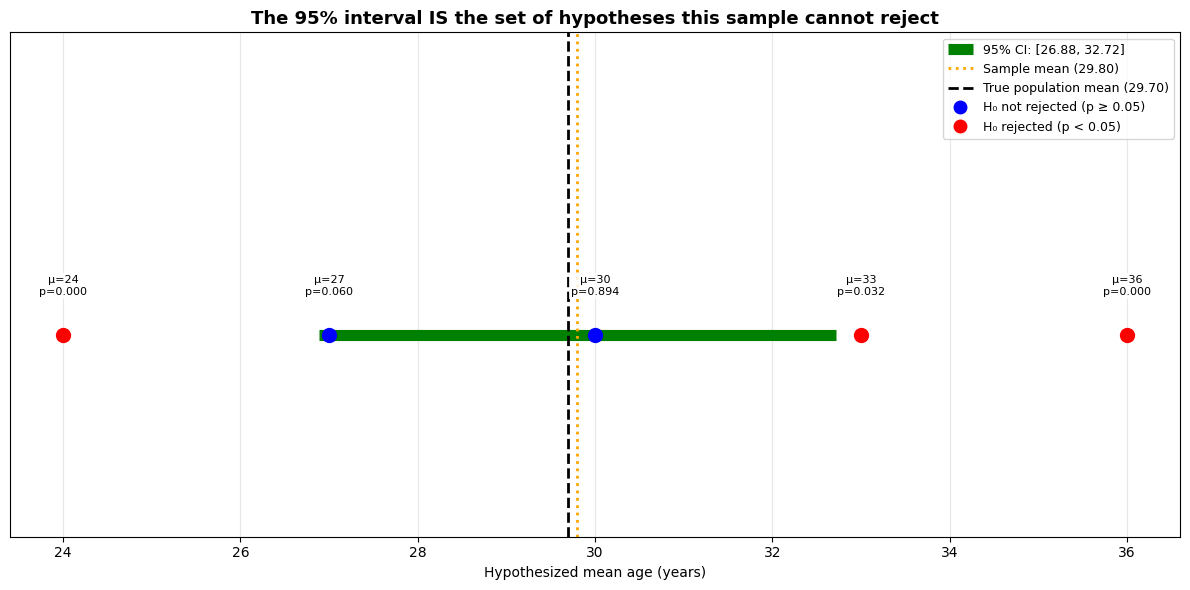


Every row obeys the same rule: 'in the interval' and 'not rejected' always agree.
The 95% CI is exactly the set of hypotheses this sample cannot reject at α = 0.05.

✅ Relationship between p-values and confidence intervals demonstrated!


In [5]:
# The duality: a value inside the 95% CI cannot be rejected at α = 0.05, one outside can.
# The table and figure below make the CI–p-value correspondence explicit.

print("\n" + "=" * 60)
print("Part 3: Relationship Between P-values and Confidence Intervals")
print("=" * 60)

# Relationship: If 95% CI excludes H0 value, p < 0.05
print("\nKey Relationship:")
print("  If 95% CI excludes the hypothesized value, then p < 0.05")
print("  If 95% CI includes the hypothesized value, then p ≥ 0.05")

# Demonstrate with different hypothesized values
hypothesized_values = [24, 27, 30, 33, 36]

print(f"\nTesting different hypothesized means:")
print(f"  95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"\nHypothesized Value | In CI? | p-value | Reject H0?")

for h0_val in hypothesized_values:
    t_stat, p_val = stats.ttest_1samp(sample, h0_val)
    in_ci = ci_lower <= h0_val <= ci_upper
    reject = p_val < 0.05
    print(f"  {h0_val:6.1f}         | {'Yes' if in_ci else 'No':5} | {p_val:.4f} | {'Yes' if reject else 'No':8}")

# Visualize. The green bar is the SAME 95% interval as the middle bar of the previous
# figure - drawn again here in its other role: as the set of hypotheses that survive.
plt.figure(figsize=(12, 6))
plt.hlines(0, ci_lower, ci_upper, colors='green', linewidth=8,
           label=f'95% CI: [{ci_lower:.2f}, {ci_upper:.2f}]')
for h0_val in hypothesized_values:
    t_stat, p_val = stats.ttest_1samp(sample, h0_val)
    color = 'red' if p_val < 0.05 else 'blue'
    plt.plot(h0_val, 0, 'o', color=color, markersize=10)
    # White backing so a label is readable even where it crosses the mean lines.
    plt.text(h0_val, 0.02, f'μ={h0_val}\np={p_val:.3f}', ha='center', fontsize=8,
             bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=1.5))
plt.axvline(sample_mean, color='orange', linestyle=':', linewidth=2,
            label=f'Sample mean ({sample_mean:.2f})')
plt.axvline(true_mean, color='black', linestyle='--', linewidth=2,
            label=f'True population mean ({true_mean:.2f})')
# Say what the dot colours mean IN the figure, not only in the text underneath it.
plt.plot([], [], 'o', color='blue', markersize=9, label='H₀ not rejected (p ≥ 0.05)')
plt.plot([], [], 'o', color='red', markersize=9, label='H₀ rejected (p < 0.05)')
plt.xlabel('Hypothesized mean age (years)')
plt.ylabel('')
plt.title('The 95% interval IS the set of hypotheses this sample cannot reject',
          fontsize=13, fontweight='bold')
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, alpha=0.3, axis='x')
plt.ylim(-0.1, 0.15)
plt.yticks([])
plt.tight_layout()
plt.show()

print("\nEvery row obeys the same rule: 'in the interval' and 'not rejected' always agree.")
print("The 95% CI is exactly the set of hypotheses this sample cannot reject at α = 0.05.")

print("\n✅ Relationship between p-values and confidence intervals demonstrated!")

**📖 What to see in the figure above.** Five candidate values for the population
mean age sit on one axis, each labelled with the p-value it earns. Every blue dot — a
hypothesis this sample cannot reject — lies **on** the green bar; every red dot lies **off**
it. That is not a coincidence to be memorised, it is the definition: the 95% confidence
interval is precisely the collection of hypothesised means that would survive a test at
α = 0.05 on this sample. The green bar is the same interval drawn as the middle bar of the
previous figure; here it is doing its other job, as a decision rule rather than a range.

---

## ⚠️ Where this breaks

- **The interval is about the procedure, not about this interval.** The notebook can *check* whether
  [26.8815, 32.7235] contains the true mean of 29.6991 only because it happens to hold the whole
  population — a luxury that never exists in practice, and the notebook says so. In a real study you never
  learn whether your one interval was one of the 19 that worked or the 1 that did not.
- **More confidence is bought with width, not with knowledge.** 90% CI width 4.89, 95% width 5.84, 99%
  width 7.73 — the same 100 observations, three different intervals. Raising your confidence level does
  not make you better informed; it makes your statement vaguer until it is safe. The only way to be both
  confident and precise is more (or better) data.
- **The duality with p-values is exact and is often over-read.** The table shows every row obeying the same
  rule: values inside the interval are exactly the hypotheses this sample cannot reject at α = 0.05. That
  makes the CI *more informative* than a p-value — it shows the whole set of surviving hypotheses — but it
  does not make any single value in the interval more likely than any other. The endpoints are not "the
  worst case"; values slightly outside are not "impossible".
- **All of it assumes the sampling model.** These intervals use the t-distribution, which assumes
  independent draws from a roughly normal population. The 177 passengers with no recorded age are excluded
  throughout, and if age was missing systematically, the interval is a precise statement about a biased
  sample. See notebook 05.


---

## 💬 Discuss

1. Write the single sentence you would put under a 95% confidence interval in a report to a non-technical
   client. Then check it against the six statements Hoekstra and colleagues found people endorse — is yours
   one of them?
2. Researchers with statistical training performed no better than students with none. What does that say
   about *how* confidence intervals are taught, and what would you change about the way this very notebook
   presents them?
3. A colleague reports a 99% CI instead of a 95% one "to be safe". What have they actually made safer, what
   have they given up, and when is that trade the right one?


## Summary

### Key Concepts:
1. **P-value**: Probability of observing data (or more extreme) if H0 is true
2. **Confidence Interval**: Range of plausible values for parameter
3. **Relationship**: 95% CI excludes H0 value ↔ p < 0.05
4. **Interpretation**: 
   - P-value: Evidence against H0 (lower = stronger evidence)
   - CI: Range of parameter values consistent with data

### Best Practices:
- Report both p-values and confidence intervals
- Don't interpret p-value as probability H0 is true
- Consider effect size, not just significance
- Use appropriate confidence level (usually 95%)

### Applications:
- Statistical inference
- Scientific reporting
- Decision making
- Quality control

**Reference:** Course 03, Unit 5: "Probability and Statistical Inference" - P-values and confidence intervals practical content

---

## 🔭 State of the field (2026)

A confidence interval is a statement about a **parameter** estimated from a sample. The question a deployed
model is asked is a different one — "how sure are you about *this* prediction?" — and the 2026 answer is
**conformal prediction**: score a held-out calibration set, take a quantile of those scores, and emit a
prediction *set* that contains the truth at a rate you chose in advance, with no assumption about the model and
only exchangeability assumed of the data (Angelopoulos & Bates 2022). It wraps any predictor, including one you
did not train, and the *size* of each set becomes a readable difficulty signal. For large language models the
same need produced a whole taxonomy of uncertainty methods, because decoding stochasticity and reasoning-path
divergence are sources of uncertainty classical statistics never had to name (Liu et al. 2025). Meanwhile the
interval you are about to build has itself been re-examined: Bowyer et al. (2025) show that CLT-based error
bars **dramatically underestimate** uncertainty on the small, specialized benchmarks now common in AI
evaluation, and recommend specific frequentist and Bayesian replacements for that regime.

**Why this lesson is still the right thing to learn.** Conformal calibration *is* a quantile of a sampling
distribution, and the Bowyer et al. warning is unreadable unless you know exactly what the t-interval below
assumes and where those assumptions come from. The official plan examines p-values and confidence intervals;
everything above is where they lead.

## 📚 References

1. Neyman, J. (1937). *Outline of a Theory of Statistical Estimation Based on the Classical Theory of Probability*. Philosophical Transactions of the Royal Society A, 236, 333–380.
2. Wasserstein, R. L., & Lazar, N. A. (2016). *The ASA Statement on p-Values: Context, Process, and Purpose*. The American Statistician, 70(2), 129–133. <https://doi.org/10.1080/00031305.2016.1154108>
3. Greenland, S., Senn, S. J., Rothman, K. J., Carlin, J. B., Poole, C., Goodman, S. N., & Altman, D. G. (2016). *Statistical Tests, P Values, Confidence Intervals, and Power: A Guide to Misinterpretations*. European Journal of Epidemiology, 31, 337–350. <https://doi.org/10.1007/s10654-016-0149-3>
4. Angelopoulos & Bates (2022). *A Gentle Introduction to Conformal Prediction and Distribution-Free Uncertainty Quantification*. arXiv. <https://arxiv.org/abs/2107.07511> — prediction sets with a coverage guarantee: the per-prediction counterpart to a confidence interval.
5. Bowyer, S., Aitchison, L., & Ivanova, D. R. (2025). *Position: Don't Use the CLT in LLM Evals With Fewer Than a Few Hundred Datapoints*. arXiv. <https://arxiv.org/abs/2503.01747> — CLT-based error bars are too narrow on small benchmarks; frequentist and Bayesian alternatives.
6. Liu, X., Chen, T., Da, L., Chen, C., Lin, Z., & Wei, H. (2025). *Uncertainty Quantification and Confidence Calibration in Large Language Models: A Survey*. arXiv. <https://arxiv.org/abs/2503.15850> — the wider 2025 landscape of uncertainty estimation for large models.
